# Racing Line Chart of Analytic Tools 

This uses an excel file in which I added a column for each tool with values that are my best guess at how much I rely on the tools. Information and the first five rows are shown below. 

The visualization was largely created by AI tools (Gemini and Claude) with my supervision and editing.

## Import Libraries

In [33]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import pandas as pd
import matplotlib.patches as mpatches

my_tools_colors = {
    "Excel": "#5D7F24",
    "Minitab": "#00A9E0",
    "R": "#DD0511",
    "SAS": "#0072C6",  # Corporate blue (distinct from Tableau and Power BI)
    "Adobe Flash": "#FF0000",
    "Python": "#3776AB",  # Official Python brand steel-blue
    "SQL": "#8B4513",  # Saddle brown
    "Tableau": "#FFC907",
    "Power BI": "#000000",  # Pure black (instantly separates from GenAI)
    "Alteryx": "#BB84A5",
    "GenAI": "#FF7F50",  # Retains coral-orange identity
    "Agentic AI": "#7C3AED",  # Electric violet/purple (maximum contrast from Python's blue)
}
df = pd.read_excel("ronsAnalyticsToolsOverTime.xlsx")
display(df.info(), df.head())

<class 'pandas.DataFrame'>
RangeIndex: 342 entries, 0 to 341
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Date         342 non-null    datetime64[us]
 1   Event        16 non-null     str           
 2   ShortEvent   14 non-null     str           
 3   Excel        338 non-null    float64       
 4   Minitab      20 non-null     float64       
 5   R            150 non-null    float64       
 6   SAS          169 non-null    float64       
 7   Adobe Flash  40 non-null     float64       
 8   Python       106 non-null    float64       
 9   Tableau      93 non-null     float64       
 10  Power BI     75 non-null     float64       
 11  Alteryx      60 non-null     float64       
 12  GenAI        52 non-null     float64       
 13  SQL          140 non-null    float64       
 14  Agentic AI   14 non-null     float64       
dtypes: datetime64[us](1), float64(12), str(2)
memory usage: 40.9 KB


None

,Date,Event,ShortEvent,Excel,Minitab,R,SAS,Adobe Flash,Python,Tableau,Power BI,Alteryx,GenAI,SQL,Agentic AI
0,1998-05-01,Working on Bachelors degree,Bachelors,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1998-06-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1998-07-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1998-08-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1998-09-01,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


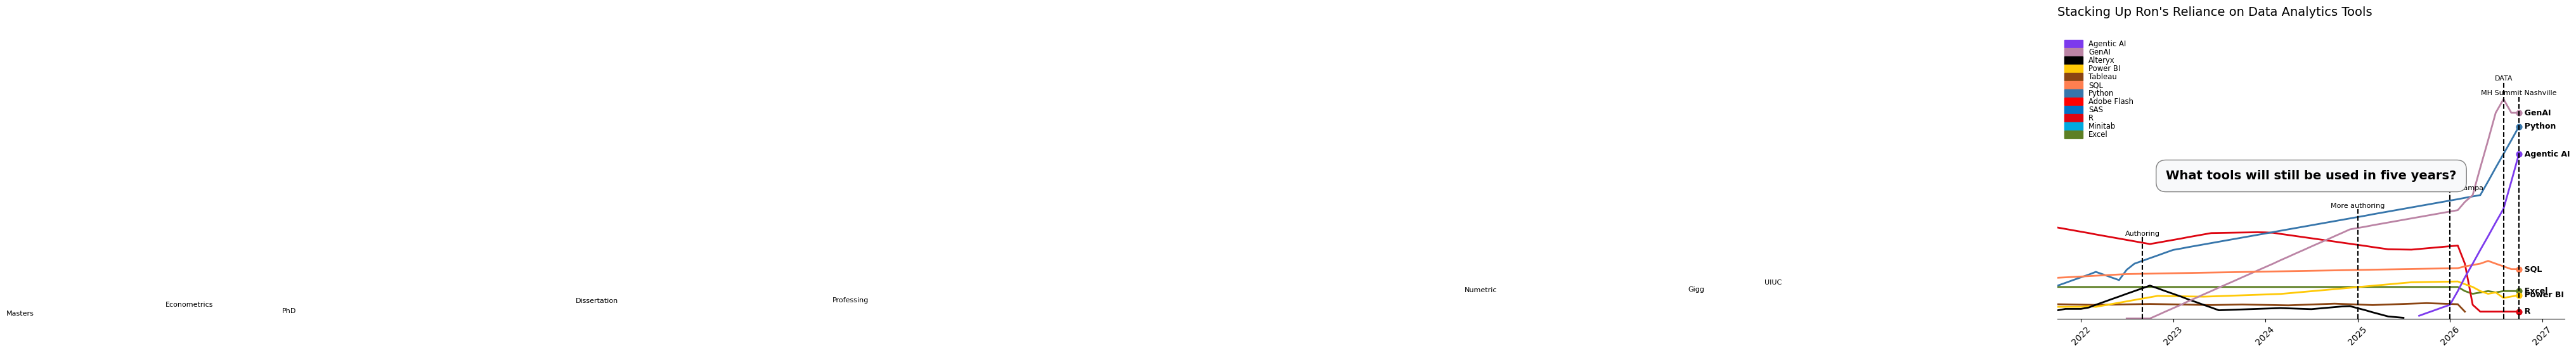

In [34]:
from PIL import Image

# my_colors = plt.get_cmap("tab20").colors
my_colors = list(my_tools_colors.values())
tools = df.columns[3:]

FULL_HISTORY_START = df["Date"].min()
FINAL_DATE = df["Date"].max()

# --- Camera-zoom finale settings ---
# Pan the left edge of the x-axis from the full history down to a fixed
# 5-year window, finishing exactly on the last frame. The pan itself starts
# ZOOM_LEAD_YEARS before the end so it's a gentle, gradual push-in rather
# than a sudden jump.
ZOOM_WINDOW_YEARS = 5
ZOOM_LEAD_YEARS = 8
ZOOM_TARGET_START = FINAL_DATE - pd.DateOffset(years=ZOOM_WINDOW_YEARS)
ZOOM_PAN_START_DATE = FINAL_DATE - pd.DateOffset(years=ZOOM_LEAD_YEARS)

# How much longer to hold the final (zoomed-in) frame, in seconds.
HOLD_SECONDS = 10


def ease_smoothstep(p):
    p = max(0.0, min(1.0, p))
    return p * p * (3 - 2 * p)


fig, ax = plt.subplots(figsize=(10, 6))


def update(frame):
    ax.clear()
    # 1. Turn off spines (the borders)
    for spine in ["top", "right", "left"]:
        ax.spines[spine].set_visible(False)

    subset = df.iloc[: frame + 1]

    # Calculate dynamic limits
    current_ymax = subset[tools].max().max()
    if pd.isna(current_ymax) or current_ymax == 0:
        current_ymax = 10

    # 2. Plotting Lines
    for i, tool in enumerate(tools):
        ax.plot(subset["Date"], subset[tool], label=tool, color=my_colors[i], lw=2)

        if not subset.empty:
            last_row = subset.iloc[-1]
            # Use ha='left' and a small offset to keep labels away from the dots
            ax.scatter(last_row["Date"], last_row[tool], color=my_colors[i], s=40)
            ax.text(
                last_row["Date"],
                last_row[tool],
                f"  {tool}",
                va="center",
                ha="left",
                fontsize=9,
                fontweight="bold",
            )

    # 3. Handle Event Lines (Horizontal labels at current peak)
    event_indices = subset[subset["ShortEvent"].notna()].index
    for idx in event_indices:
        e_date, e_name = df.loc[idx, "Date"], df.loc[idx, "ShortEvent"]
        e_max = df.iloc[idx][tools].max()
        label_y = e_max * 1.08
        ax.vlines(
            x=e_date, ymin=0, ymax=label_y, color="black", linestyle="--", alpha=1
        )
        ax.text(x=e_date, y=label_y, s=e_name, ha="center", va="bottom", fontsize=8)

    # 4. Relocate Legend to the LEFT inside the plot (Jenga Block Style)

    # Use the order of the tools from the mmy_tools_colors dictionary
    tool_order = list(my_tools_colors.keys())
    
    # Reverse the list so Agentic AI is at the top of the legend stack
    ordered_labels = tool_order[::-1]
    
    # Grab the current lines from the plot to get their assigned colors
    handles, labels = ax.get_legend_handles_labels()
    color_dict = {l: h.get_color() for h, l in zip(handles, labels)}
    
    # Build the Jenga blocks, ensuring we only include tools currently visible
    jenga_blocks = []
    final_labels = []
    for tool in ordered_labels:
        if tool in color_dict:
            jenga_blocks.append(mpatches.Patch(color=color_dict[tool], label=tool))
            final_labels.append(tool)
            
    ax.legend(
        handles=jenga_blocks,
        labels=final_labels,
        loc="upper left", 
        frameon=False, 
        fontsize="small",
        labelspacing=0.0,       # Removes vertical gaps to "stack" the blocks
        handlelength=2.5,       # Makes the blocks wider
        handleheight=1.2        # Makes the blocks thicker
    )

    # 5. X-Axis: expand through history, then camera-zoom into the last
    # ZOOM_WINDOW_YEARS years as we approach the final frame.
    if not subset.empty:
        current_date = subset["Date"].max()

        pan_span = (FINAL_DATE - ZOOM_PAN_START_DATE).days
        progress = (
            (current_date - ZOOM_PAN_START_DATE).days / pan_span if pan_span else 1.0
        )
        p = ease_smoothstep(progress)

        xmin = FULL_HISTORY_START + p * (ZOOM_TARGET_START - FULL_HISTORY_START)
        # Right-side buffer shrinks from 18 months down to 6 as we zoom in,
        # so the finale doesn't waste space on empty future dates.
        buffer_days = 548 - p * (548 - 182)
        xmax = current_date + pd.Timedelta(days=buffer_days)
        ax.set_xlim(xmin, xmax)

    # 6. Final Polish
    ax.set_ylim(0, current_ymax * 1.3)
    ax.set_yticklabels([])  # Keep y-axis clean
    ax.set_yticks([])
    ax.set_title(
        "Stacking Up Ron's Reliance on Data Analytics Tools", loc="left", pad=20, fontsize=14
    )
    plt.xticks(rotation=45) 

    # NEW: Add the concluding statement on the final frame
    if frame == len(df) - 1:
        ax.text(
            0.5, 0.5,  # Centers the text in the middle of the plot
            "What tools will still be used in five years?",
            transform=ax.transAxes,  # Uses relative axis coordinates (0 to 1)
            fontsize=14,
            fontweight="bold",
            ha="center",
            va="center",
            bbox=dict(boxstyle="round,pad=0.8", facecolor="#f8f9fa", edgecolor="gray", alpha=1.0, zorder=10)
        )

    # Manual margin control - giving the right side plenty of room
    plt.subplots_adjust(right=0.85, left=0.05, top=0.9, bottom=0.15)


# Save the animation
ani = FuncAnimation(fig, update, frames=len(df), interval=300)
ani.save("racing_line_chart_with_labels.gif", writer="pillow", fps=5)
plt.show()

# Hold the final (zoomed-in) frame a few extra seconds so viewers have time
# to read it before the gif loops. We do this as a post-processing pass on
# the saved gif rather than by repeating the last frame index above,
# because Pillow's GIF writer silently collapses identical consecutive
# frames, which would otherwise erase the hold.
with Image.open("racing_line_chart_with_labels.gif") as gif:
    frames, durations = [], []
    for i in range(gif.n_frames):
        gif.seek(i)
        frames.append(gif.convert("RGBA"))
        durations.append(gif.info.get("duration", 200))
    durations[-1] += HOLD_SECONDS * 1000
    frames[0].save(
        "racing_line_chart_with_labels.gif",
        save_all=True,
        append_images=frames[1:],
        duration=durations,
        loop=0,
        disposal=2,
    )